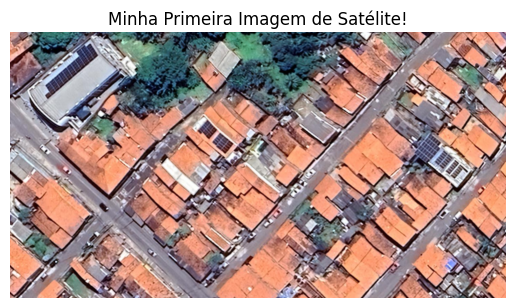

In [5]:
# Importando as bibliotecas necessárias
import cv2
import matplotlib.pyplot as plt

# 1. Carregando a imagem que você acabou de salvar
# ATENÇÃO: Se você salvou como .jpg, mude o nome aqui no código!
imagem_telhado = cv2.imread('telhado.png')

# 2. Corrigindo o "Efeito Smurf" (MUITO IMPORTANTE)
# O OpenCV (cv2) lê as imagens com as cores invertidas, no formato BGR (Azul, Verde, Vermelho).
# O Matplotlib (plt) exibe as imagens no formato normal, RGB (Vermelho, Verde, Azul).
# Se não convertermos, o telhado vai ficar azul e a grama vermelha!
imagem_corrigida = cv2.cvtColor(imagem_telhado, cv2.COLOR_BGR2RGB)

# 3. Exibindo a imagem de satélite
plt.imshow(imagem_corrigida)
plt.title("Minha Primeira Imagem de Satélite!")
plt.axis('off') # Esconde os números das bordas
plt.show()

In [ ]:

#Aqui vamos baixar o dataset do Roboflow para treinar o modelo de segmentação de painéis solares. Certifique-se de ter a biblioteca 'roboflow' instalada para executar este código.
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="TFvSdGfqhO8hNNWQN7XP")
project = rf.workspace("eqtl").project("solar-panel-segmentation-6bnfp")
version = project.version(1)
dataset = version.download("yolov8")
                


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.8 MB 8.4 MB/s eta 0:00:05
   - -------------------------------------- 1.6/38.8 MB 9.3 MB/s eta 0:00:04
   --- ------------------------------------ 3.4/38.8 MB 6.3 MB/s eta 0:00:06
   ------ --------------------------------- 6.0/38.8 MB 8.0 MB/s eta 0:00:05
   -------- ------------------------------- 8.4/38.8 MB 8.8 MB/s eta 0:00:04
   ----------- ---------------------------- 11.0/38.8 MB 9.4 MB/s eta 0:00:03
   ------------- -------------------------- 13.4/38.8 MB 9.8 MB/s eta 0:00:03
   ---------------- ----------------------- 16.0/38.8 MB 10.1 MB/s eta 0:00:03
   ------------------ --------------------- 18.4/38.8 MB 10.2 MB/s eta 0:00:02
   --------------------- ------------------ 21.0/38.8 MB 10.4 MB/s eta 0:00:02
   ---------------


Extracting Dataset Version Zip to solar-panel-segmentation-1 in yolov8:: 100%|██████████| 7119/7119 [00:07<00:00, 919.17it/s] 


In [ ]:

#O que faz resumidamente todo este codigo:
#Este codigo treina um modelo de inteligência artificial para identificar painéis solares em imagens de satélite. Ele usa a biblioteca YOLOv8 para criar um modelo de segmentação, que é capaz de desenhar polígonos ao redor dos painéis solares nas imagens. O código carrega um modelo pré-treinado, aponta para o dataset de treinamento, e inicia o processo de treinamento, ajustando o modelo para reconhecer os painéis solares com base nas imagens fornecidas. No final, ele gera gráficos de desempenho para avaliar como o modelo está aprendendo.
from ultralytics import YOLO

print("Carregando o motor do YOLOv8...")

# 1. Carregar um modelo "zerado" de Segmentação (desenhar polígonos)
# Usamos a versão "n" (Nano), que é a mais leve e rápida para rodar em computadores comuns
modelo = YOLO("yolov8n-seg.pt") 

# 2. Apontar para o mapa do tesouro (Substitua pelo nome da SUA pasta se for diferente)
caminho_yaml = "solar-panel-segmentation-1/data.yaml"

# 3. Iniciar o Treinamento!
print("Iniciando os estudos da IA. Aqueça os motores!")
resultados = modelo.train(
    data=caminho_yaml,
    epochs=3,       # Quantas vezes a IA vai ler o livro todo (3 é só para teste)
    imgsz=640,      # A IA vai padronizar o tamanho das imagens para 640x640 pixels
    device="cpu",   # Dizemos ao VS Code para usar o processador normal do seu PC
    plots=True      # Pede para o YOLO gerar gráficos de desempenho no final
)

print("Treinamento de teste concluído!")

Carregando o motor do YOLOv8...
Iniciando os estudos da IA. Aqueça os motores!
Ultralytics 8.4.33  Python-3.12.10 torch-2.11.0+cpu CPU (AMD Ryzen 5 1600 Six-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=solar-panel-segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, 

: 

In [1]:
import torch

print("A IA consegue ver minha placa de vídeo?")
print(torch.cuda.is_available())

A IA consegue ver minha placa de vídeo?
False
